In [3]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import os
from global_vars import *

train_folder = os.path.join(data_folder, 'nodeep_train_data_ver1/')
X_train_val = pd.read_parquet(os.path.join(train_folder, "X_train.parquet"),engine="fastparquet")


def evaluate_pca(X, n_components=None, thresholds=(0.90, 0.95, 0.99)):
    """Fit PCA and report how many components are needed to retain variance.
    X: (n_samples, n_features) — your input features."""
    # PCA is variance-based, so features must be scaled or large-magnitude
    # ones dominate purely through their units (your RF didn't care; PCA does)
    Xs = StandardScaler().fit_transform(X)

    pca = PCA(n_components=n_components)
    pca.fit(Xs)

    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)

    # how many components to cross each variance threshold
    print(f"{X.shape[1]} original features\n")
    for t in thresholds:
        k = int(np.searchsorted(cum, t) + 1)
        print(f"  {t:.0%} of variance retained by {k} components "
              f"({k/X.shape[1]:.1%} of original)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(evr) + 1), evr, marker=".")
    ax1.set_xlabel("component"); ax1.set_ylabel("variance explained")
    ax1.set_title("scree plot (per-component)")
    ax2.plot(range(1, len(cum) + 1), cum, marker=".")
    for t in thresholds:
        ax2.axhline(t, ls="--", alpha=0.4)
    ax2.set_xlabel("n components"); ax2.set_ylabel("cumulative variance")
    ax2.set_title("cumulative variance explained")
    plt.tight_layout(); plt.show()

    return pca, cum

Tin
58 original features

  90% of variance retained by 3 components (5.2% of original)
  95% of variance retained by 4 components (6.9% of original)
  99% of variance retained by 8 components (13.8% of original)


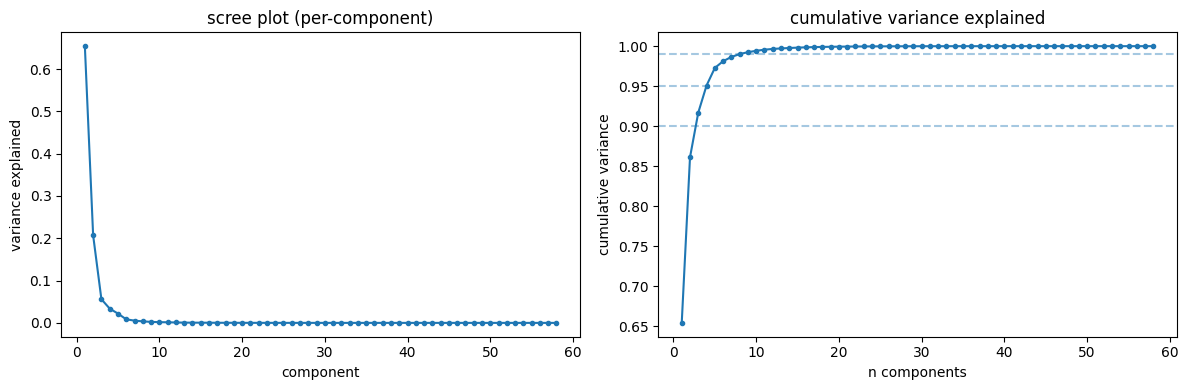

qin
58 original features

  90% of variance retained by 6 components (10.3% of original)
  95% of variance retained by 9 components (15.5% of original)
  99% of variance retained by 18 components (31.0% of original)


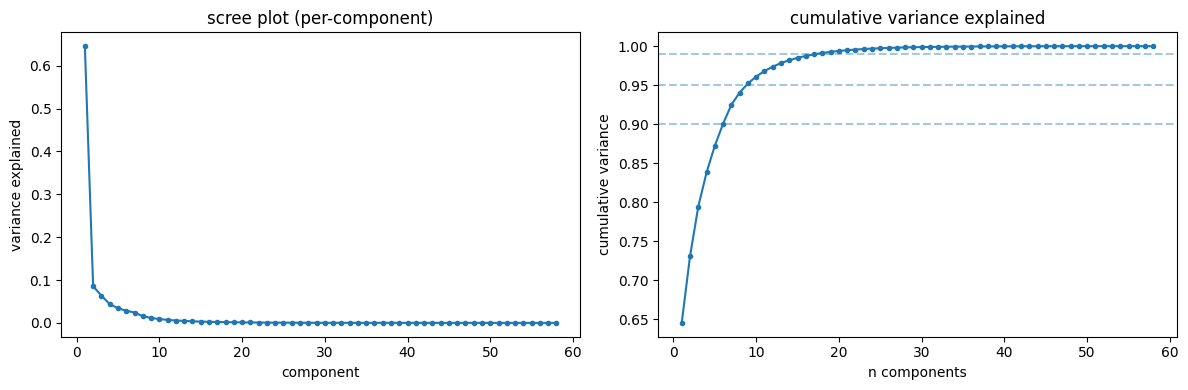

Uin
58 original features

  90% of variance retained by 3 components (5.2% of original)
  95% of variance retained by 5 components (8.6% of original)
  99% of variance retained by 10 components (17.2% of original)


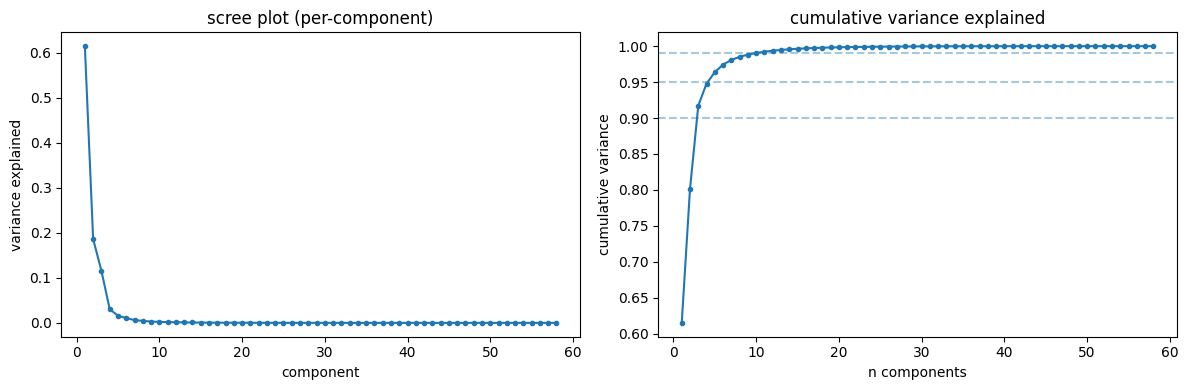

vinMinusSH
58 original features

  90% of variance retained by 4 components (6.9% of original)
  95% of variance retained by 6 components (10.3% of original)
  99% of variance retained by 14 components (24.1% of original)


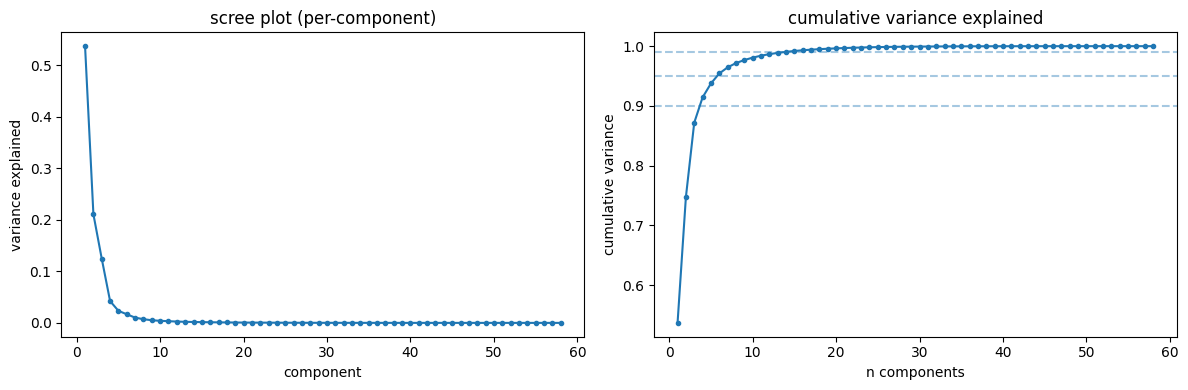

In [4]:
for var in lev_input_var_names:
    print(var)
    cols = [f'{var}_lev{i}' for i in range(58)]
    pca, cum = evaluate_pca(X_train_val[cols].values)

237 original features

  90% of variance retained by 15 components (6.3% of original)
  95% of variance retained by 24 components (10.1% of original)
  99% of variance retained by 52 components (21.9% of original)


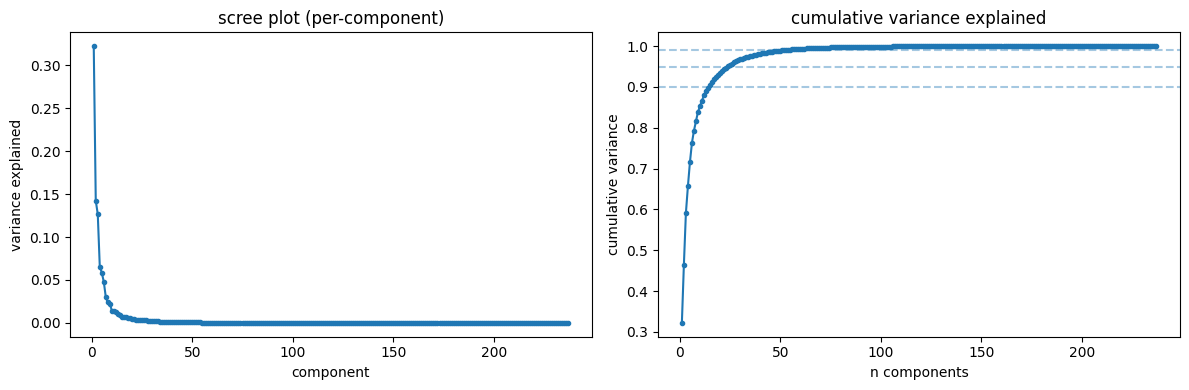

In [5]:
pca, cum = evaluate_pca(X_train_val.values)

In [7]:
y_t_train_val = pd.read_parquet(os.path.join(train_folder, "y_t_train.parquet"),engine="fastparquet")
y_q_train_val = pd.read_parquet(os.path.join(train_folder, "y_q_train.parquet"),engine="fastparquet")

In [25]:
## sample 200 random rows from X, sort by y, then plot.

n = X_train_val.shape[0]
rng = np.random.default_rng(0)
picks = rng.choice(n, size=200, replace=False)


X_sub = X_train_val.loc[picks]
y_t_sub = y_t_train_val.loc[picks]
y_q_sub = y_q_train_val.loc[picks]

order_t_57 = y_t_sub['DTCOND_lev57'].sort_values().index
order_q_57 = y_q_sub['DCQ_lev57'].sort_values().index
order_t_sum = y_t_sub.sum(axis=1).sort_values().index
order_q_sum = y_q_sub.sum(axis=1).sort_values().index
X_sub_sorted_t_57 = X_sub.loc[order_t_57]
X_sub_sorted_q_57 = X_sub.loc[order_q_57]
X_sub_sorted_t_sum = X_sub.loc[order_t_sum]
X_sub_sorted_q_sum = X_sub.loc[order_q_sum]

X_sub

,Tin_lev0,Tin_lev1,Tin_lev2,Tin_lev3,Tin_lev4,Tin_lev5,Tin_lev6,Tin_lev7,Tin_lev8,Tin_lev9,...,vinMinusSH_lev53,vinMinusSH_lev54,vinMinusSH_lev55,vinMinusSH_lev56,vinMinusSH_lev57,usurf,LANDFRAC,ICEFRAC,PHIS,SOLIN
index,,,,,,,,,,,,,,,,,,,,,
1277937,234.835497,239.193338,231.895834,222.626613,215.355962,207.853762,202.732926,200.243757,199.310907,198.853118,...,-5.493624,-4.740432,-4.478840,-4.668576,-5.364410,4.232547,0.000000,0.991898,0.000000,0.000000
1609575,264.768963,250.855529,242.630430,238.158793,235.381723,233.215785,232.645985,232.519393,232.388389,232.217271,...,-4.405018,-4.430744,-4.338852,-4.208701,-3.988515,4.697846,0.000000,0.150379,0.000000,867.604697
602480,263.268394,250.780468,238.817578,227.037529,220.228999,214.896388,209.458345,201.927524,195.173170,193.633205,...,-8.857013,-8.576696,-8.401515,-8.184533,-7.616154,7.300153,0.199128,0.000000,43.186226,0.000000
809560,256.740015,245.081593,233.680393,228.249239,226.211650,225.809455,226.174141,226.709021,227.051693,227.327617,...,-3.355621,-3.382064,-3.419035,-3.431228,-3.330384,3.953794,0.000000,0.000000,0.000000,802.324050
200843,249.133250,249.485579,244.563268,232.406928,223.949994,218.910676,216.293900,215.253445,214.276692,213.099059,...,5.734767,5.259781,4.552655,3.582810,1.377131,2.259264,1.000000,0.000000,14042.407131,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760045,228.675281,235.869690,233.548277,227.004858,221.927851,218.788957,216.763903,216.407786,217.383446,218.602081,...,-2.499088,-2.309221,-2.004669,-1.676701,-0.896932,1.176703,0.661935,0.232132,5397.115342,0.000000
1565693,232.721517,234.603690,231.964304,232.301607,234.197093,235.133689,231.867764,225.691836,219.669706,215.325614,...,-22.707142,-22.480671,-22.209801,-21.805974,-20.692608,20.343579,0.000000,0.011382,0.000000,0.000000
1666066,237.686690,242.730333,236.751173,226.685389,218.382693,215.400276,214.771927,215.257586,216.701891,216.326887,...,12.561049,11.195078,9.528132,7.556262,4.016593,3.596947,1.000000,0.000000,17169.297695,0.000000


T, Q tendencies, sorted by bottom level


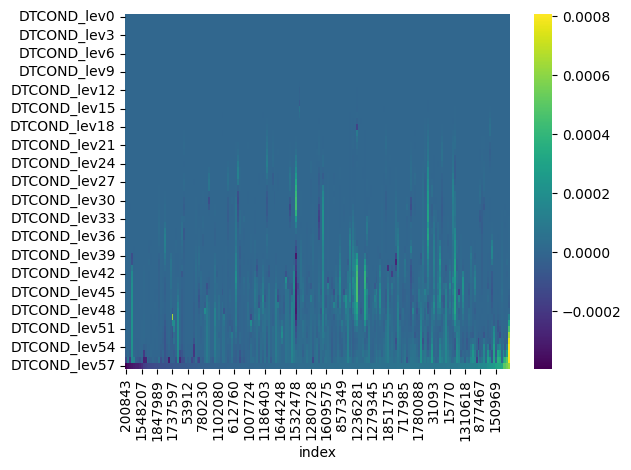

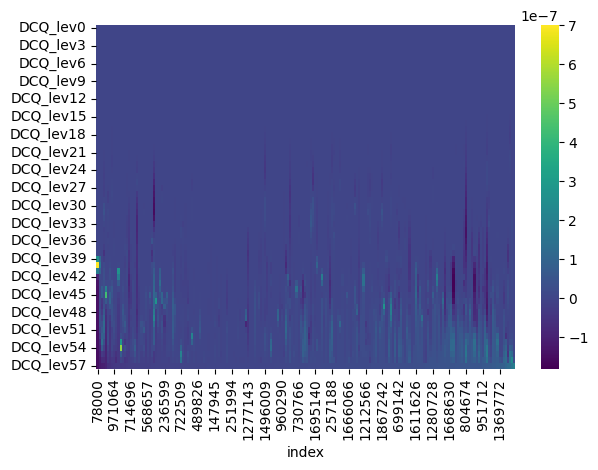

T, Q tendencies, sorted by total sum


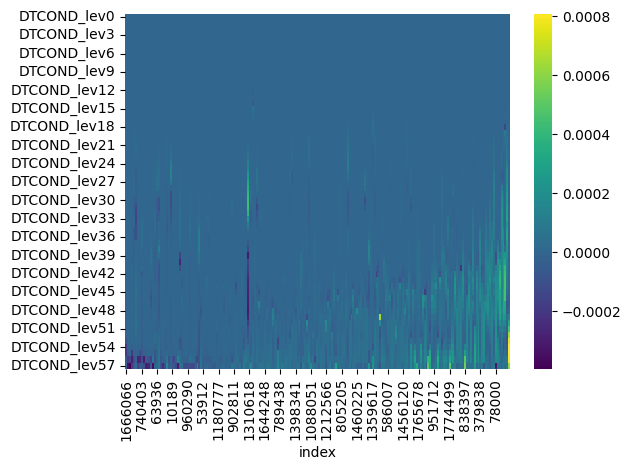

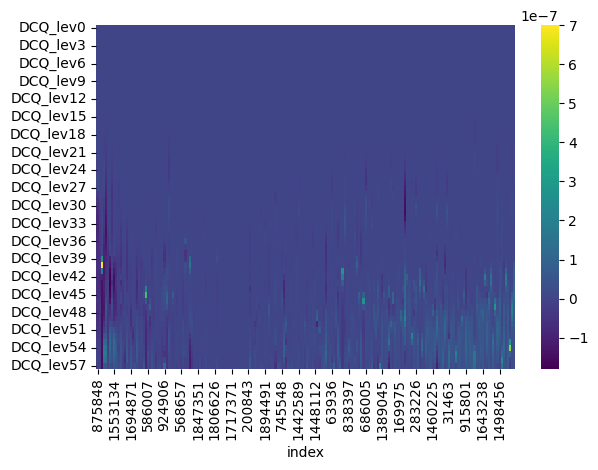

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

print('T, Q tendencies, sorted by bottom level')

sns.heatmap(y_t_sub.loc[order_t_57].T, annot=False, cmap="viridis")
plt.tight_layout()
plt.show()

sns.heatmap(y_q_sub.loc[order_q_57].T, annot=False, cmap="viridis")
plt.tight_layout()
plt.show()

print('T, Q tendencies, sorted by total sum')### NOT integrated, just the sum of all tendencies

sns.heatmap(y_t_sub.loc[order_t_sum].T, annot=False, cmap="viridis")
plt.tight_layout()
plt.show()

sns.heatmap(y_q_sub.loc[order_q_sum].T, annot=False, cmap="viridis")
plt.tight_layout()
plt.show()

Tin T tendency, bottom layer


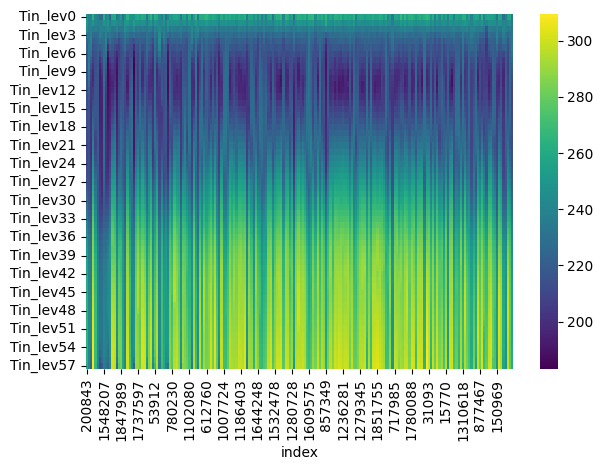

Tin T tendency, sum


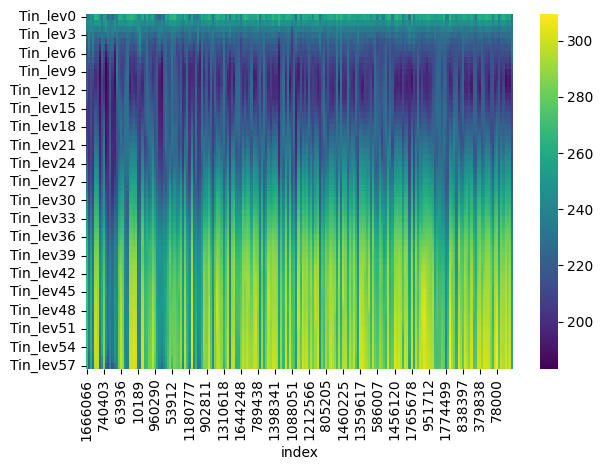

Tin Q tendency, bottom layer


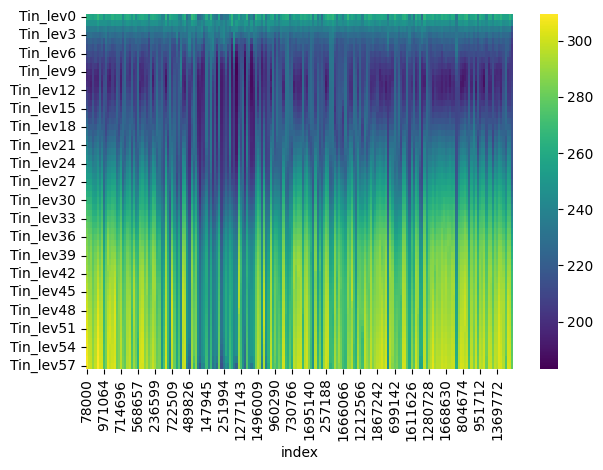

Tin Q tendency, sum


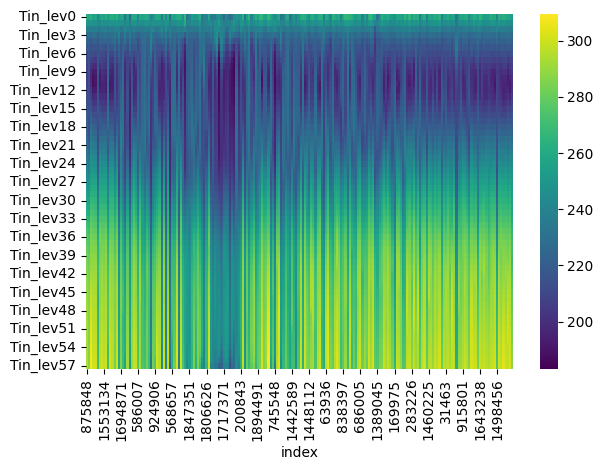

qin T tendency, bottom layer


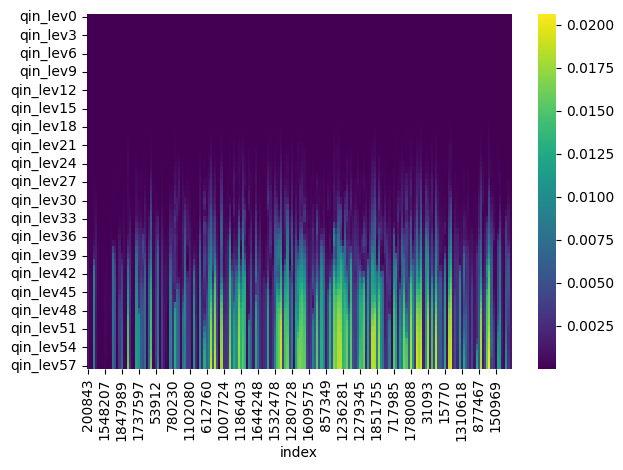

qin T tendency, sum


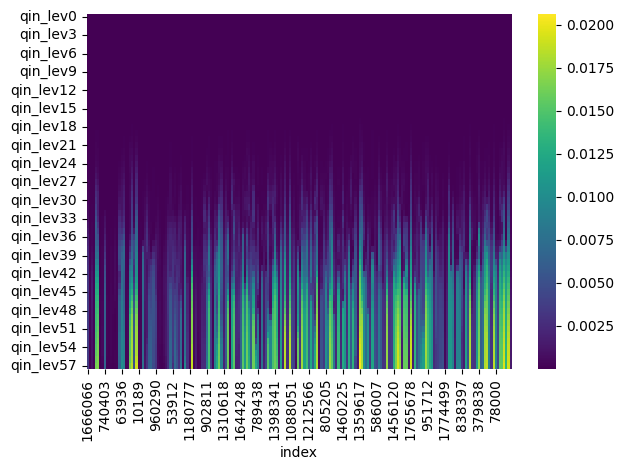

qin Q tendency, bottom layer


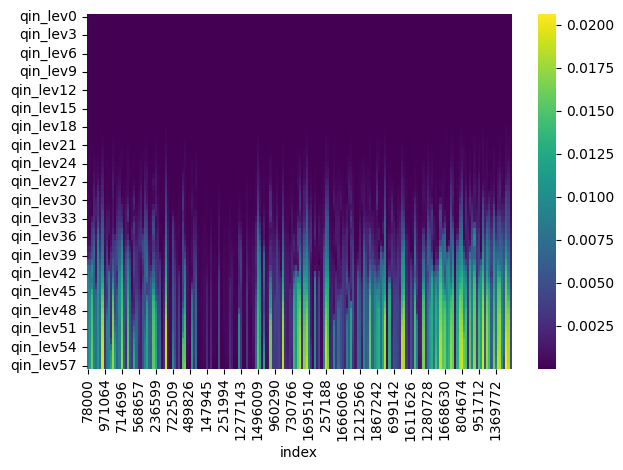

qin Q tendency, sum


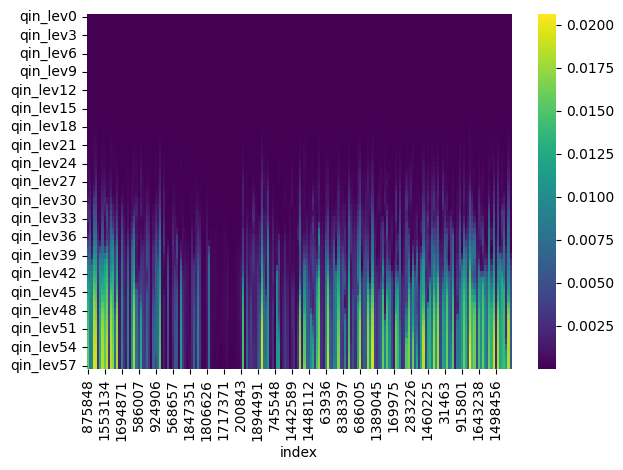

Uin T tendency, bottom layer


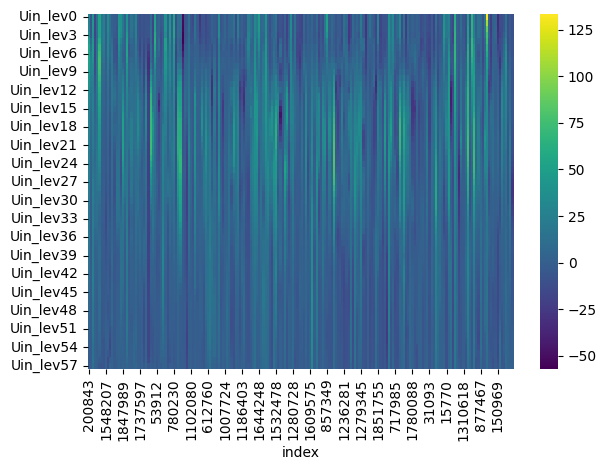

Uin T tendency, sum


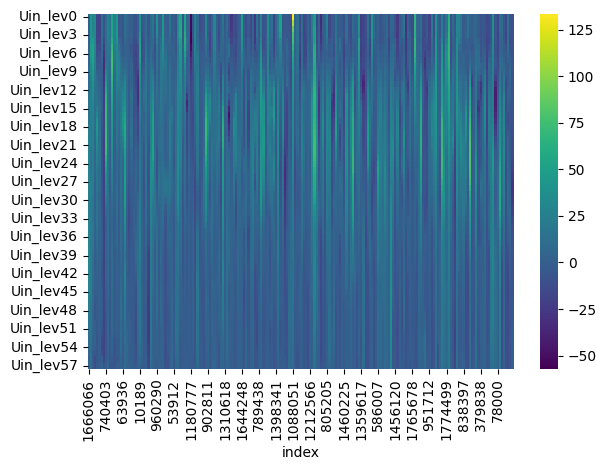

Uin Q tendency, bottom layer


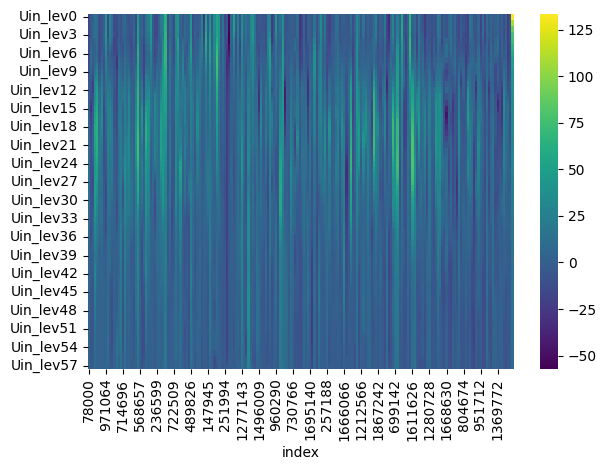

Uin Q tendency, sum


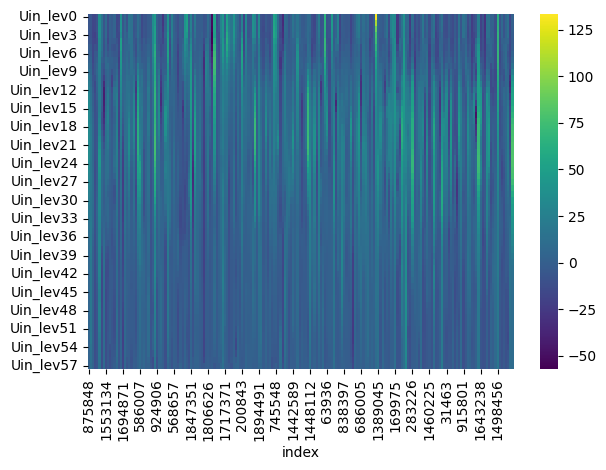

vinMinusSH T tendency, bottom layer


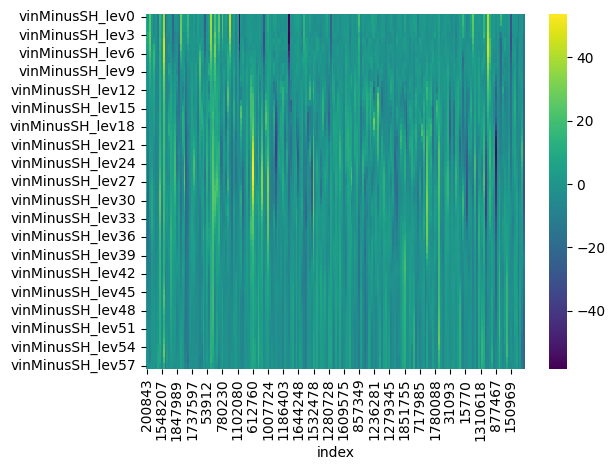

vinMinusSH T tendency, sum


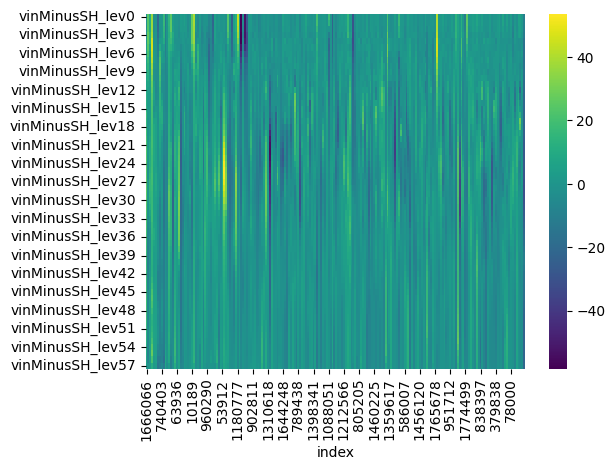

vinMinusSH Q tendency, bottom layer


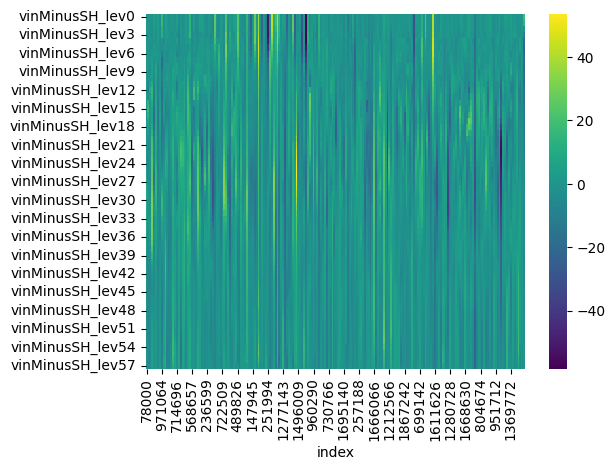

vinMinusSH Q tendency, sum


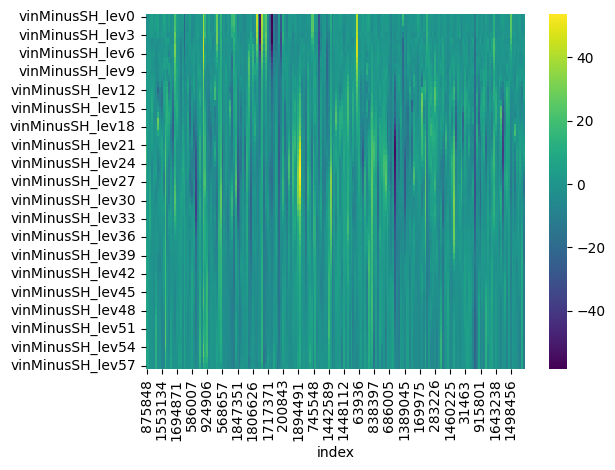

In [26]:
for var in lev_input_var_names:
    cols = [f'{var}_lev{i}' for i in range(58)]

    print(f'{var} T tendency, bottom layer')
    sns.heatmap(X_sub_sorted_t_57[cols].T, annot=False, cmap="viridis")
    plt.tight_layout()
    plt.show()

    print(f'{var} T tendency, sum')
    sns.heatmap(X_sub_sorted_t_sum[cols].T, annot=False, cmap="viridis")
    plt.tight_layout()
    plt.show()

    print(f'{var} Q tendency, bottom layer')
    sns.heatmap(X_sub_sorted_q_57[cols].T, annot=False, cmap="viridis")
    plt.tight_layout()
    plt.show()

    print(f'{var} Q tendency, sum')
    sns.heatmap(X_sub_sorted_q_sum[cols].T, annot=False, cmap="viridis")
    plt.tight_layout()
    plt.show()

Observations:

In the area where tendencies are ~0, there is usually low temperature and very low humidity, other than that idk what is going on.

In [17]:
y_q_sub

,DCQ_lev0,DCQ_lev1,DCQ_lev2,DCQ_lev3,DCQ_lev4,DCQ_lev5,DCQ_lev6,DCQ_lev7,DCQ_lev8,DCQ_lev9,...,DCQ_lev48,DCQ_lev49,DCQ_lev50,DCQ_lev51,DCQ_lev52,DCQ_lev53,DCQ_lev54,DCQ_lev55,DCQ_lev56,DCQ_lev57
index,,,,,,,,,,,,,,,,,,,,,
1277937,-1.745564e-18,9.542533e-19,2.319285e-18,-8.813806e-18,-2.157726e-17,-4.046062e-17,-5.966783e-17,-5.846148e-17,-6.885095e-17,-7.874712e-17,...,-1.230214e-10,-1.455693e-10,-1.520107e-10,-1.427800e-10,-1.413503e-10,-1.799493e-10,-2.708954e-10,-4.879055e-10,-7.585181e-10,2.004373e-09
1609575,-2.223120e-17,-5.680910e-17,-3.934523e-17,-3.227252e-17,-4.984423e-18,-2.103539e-17,-1.061221e-16,-8.078371e-17,7.987272e-17,2.566113e-17,...,-9.372368e-09,-2.292404e-08,-1.759190e-08,4.701971e-09,6.530118e-09,6.112289e-09,8.387035e-09,5.700780e-09,5.398261e-10,-5.392559e-10
602480,-1.783399e-17,-5.313739e-17,-1.440162e-17,5.958048e-18,-3.308763e-19,-5.206815e-17,-3.177437e-16,-5.698616e-16,4.253369e-17,2.375151e-15,...,1.133507e-10,7.941733e-11,9.399174e-10,1.205352e-08,6.672136e-08,7.652716e-08,4.937914e-08,5.420478e-08,5.483200e-08,5.152243e-08
809560,-1.674535e-17,-6.250012e-17,-6.543197e-17,-5.232742e-17,-3.849767e-17,-3.818929e-17,-3.425847e-17,-2.614272e-17,-1.040391e-17,3.616386e-17,...,-1.406276e-08,1.610580e-09,1.780127e-08,2.167374e-08,1.424735e-08,1.352184e-08,1.601317e-08,1.785023e-08,1.360024e-08,-4.123253e-10
200843,7.624553e-19,-8.572904e-17,-1.669807e-16,-2.448122e-17,2.594736e-17,-2.675062e-17,1.113413e-17,5.644053e-17,4.500485e-17,2.767234e-17,...,1.086952e-10,2.641936e-11,-1.022978e-10,-8.741880e-11,-1.011670e-11,-1.152111e-10,-3.569532e-10,-8.424620e-10,1.915463e-10,2.320716e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760045,-2.618995e-18,-1.215432e-17,6.812886e-17,-5.910887e-18,-1.388132e-16,-1.739639e-16,-1.566451e-16,2.960278e-17,3.595980e-16,3.321150e-16,...,5.184314e-09,4.677447e-09,4.202152e-09,3.450822e-09,3.250188e-09,2.827071e-09,2.434210e-09,2.189843e-09,4.331031e-09,1.351426e-08
1565693,-5.195052e-18,-9.371648e-17,-1.085662e-16,2.375980e-16,2.429658e-16,3.699021e-17,-2.532589e-16,-3.423410e-16,-2.872326e-16,-2.193474e-16,...,9.262168e-09,1.515088e-08,3.267716e-08,5.375983e-08,6.399581e-08,6.349230e-08,5.956601e-08,5.808053e-08,5.552533e-08,4.906988e-08
1666066,-1.035668e-18,-7.070900e-17,-1.562073e-16,-8.966169e-17,-1.130002e-17,3.720358e-17,-7.586950e-18,-8.711657e-17,-6.133415e-18,1.129851e-16,...,5.707120e-09,5.820949e-09,6.327654e-09,6.560956e-09,5.690386e-09,9.429262e-09,1.225079e-08,1.897073e-08,3.057858e-08,1.598548e-08


In [ ]:





y_t_train_val.

In [6]:
X_train_val

,Tin_lev0,Tin_lev1,Tin_lev2,Tin_lev3,Tin_lev4,Tin_lev5,Tin_lev6,Tin_lev7,Tin_lev8,Tin_lev9,...,vinMinusSH_lev53,vinMinusSH_lev54,vinMinusSH_lev55,vinMinusSH_lev56,vinMinusSH_lev57,usurf,LANDFRAC,ICEFRAC,PHIS,SOLIN
index,,,,,,,,,,,,,,,,,,,,,
0,231.534233,240.616546,239.764657,232.156300,218.942451,206.361429,196.529437,189.244822,186.728324,186.079821,...,8.531515,9.224373,11.751842,12.783870,7.128604,9.386902,1.0,0.0,26423.069839,0.0
1,231.288278,240.686761,239.781098,231.820017,218.931926,206.149704,195.850832,190.006002,186.856892,185.752976,...,-9.609911,-10.180888,-10.757395,-13.893887,-12.209468,9.471548,1.0,0.0,28076.802709,0.0
2,231.148042,240.249383,240.109710,231.646328,219.136626,205.781115,196.150920,189.331268,186.019240,185.872242,...,-0.803532,0.026606,0.608704,2.265774,6.708505,6.238574,1.0,0.0,29153.826686,0.0
3,231.114185,240.822210,239.653774,231.845096,218.952715,206.102893,195.827739,190.000868,186.787645,185.742951,...,-10.514206,-10.549034,-11.098464,-13.954485,-11.875989,9.323620,1.0,0.0,28170.762491,0.0
4,231.306535,240.369421,239.917989,231.846031,219.138685,205.897845,196.162286,189.419236,186.211258,185.825966,...,2.369670,3.017650,3.306900,4.646591,8.850308,7.725826,1.0,0.0,28693.045950,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1904395,253.280479,237.977858,230.830833,222.515585,212.305040,202.946989,196.461924,193.355396,192.380965,192.480253,...,-7.726142,-8.284198,-8.994821,-8.434332,-6.958676,5.056033,0.0,1.0,0.000000,0.0
1904396,253.320635,238.127589,231.003949,222.779119,212.126292,203.065515,196.616932,193.382999,192.168019,192.301246,...,0.183473,-0.036928,-0.947266,-1.144232,-3.475727,5.533280,0.0,1.0,0.000000,0.0
1904397,249.527664,238.211793,230.457220,221.920657,213.271263,204.951443,197.151132,193.507506,193.054252,193.483366,...,6.482011,6.674149,7.180957,7.104491,6.924756,5.138983,0.0,1.0,0.000000,0.0
